<a href="https://colab.research.google.com/github/Cursed06/Sepsis-Computational-Biology/blob/main/Machine_Learning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pembersihan Data dari CSV**

In [ ]:
#import dataset di runtime

from google.colab import files

uploaded = files.upload()

Saving sepsis_gene_expression_LABELED.csv to sepsis_gene_expression_LABELED.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
df_lengkap = pd.read_csv('sepsis_gene_expression_LABELED.csv', sep=';', low_memory=False)

print("Sedang mengekstrak label dan memperbaiki format angka...")

# Membersihkan kolom corrupt
status_list = []
for index, row in df_lengkap.iterrows():
    baris_teks = row.astype(str).str.lower().str.strip().values
    if 'sepsis' in baris_teks:
        status_list.append(1)
    elif 'control' in baris_teks:
        status_list.append(0)
    else:
        status_list.append(np.nan)

df_lengkap['Target_Bersih'] = status_list
df_lengkap = df_lengkap.dropna(subset=['Target_Bersih'])

kolom_id = df_lengkap.columns[0]
X = df_lengkap.drop([kolom_id, 'Target_Bersih'], axis=1)
X = X.loc[:, ~X.columns.str.contains('^Unnamed')]

# Memperbaiki format angka dari excel
def perbaiki_angka(nilai):
    teks = str(nilai).strip()
    if teks.lower() in ['nan', 'none', '']: return np.nan

    teks = teks.replace(',', '.')

    bagian = teks.split('.')
    if len(bagian) > 2:
        teks = bagian[0] + '.' + ''.join(bagian[1:])

    try:
        return float(teks)
    except:
        return np.nan

for col in X.columns:
    X[col] = X[col].map(perbaiki_angka)

X = X.dropna(axis=1, thresh=int(0.8 * len(X)))
X = X.fillna(0)

y = df_lengkap['Target_Bersih']

# Split data Train dan Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("TAHAP 1 SUKSES TOTAL!")
print("Jumlah Baris Train:", X_train.shape[0])
print("Jumlah Baris Test:", X_test.shape[0])
print("Jumlah Kolom Gen Siap Pakai:", X_train.shape[1])

Sedang mengekstrak label dan memperbaiki format angka...
TAHAP 1 SUKSES TOTAL!
Jumlah Baris Train: 641
Jumlah Baris Test: 161
Jumlah Kolom Gen Siap Pakai: 2402


**Logistic Regression L1**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pandas as pd

print("="*60)
print("DATA SCALING & L1 LOGISTIC REGRESSION (BASE)")
print("="*60)

print("Sedang melakukan standardisasi (scaling) pada data genetik...")
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train Scaled : {X_train_scaled.shape}")
print(f"Test Scaled  : {X_test_scaled.shape}")

print("\nSedang melatih model Logistic Regression L1 (Base)...")
l1_base_model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42)
l1_base_model.fit(X_train_scaled, y_train)

l1_pred = l1_base_model.predict(X_test_scaled)
l1_prob = l1_base_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy : {accuracy_score(y_test, l1_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, l1_prob):.4f}")

print("\nClassification Report")
print(classification_report(y_test, l1_pred))

DATA SCALING & L1 LOGISTIC REGRESSION (BASE)
Sedang melakukan standardisasi (scaling) pada data genetik...
Train Scaled : (641, 2402)
Test Scaled  : (161, 2402)

Sedang melatih model Logistic Regression L1 (Base)...

Accuracy : 0.9130
ROC-AUC  : 0.5629

Classification Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      0.96      0.95       153

    accuracy                           0.91       161
   macro avg       0.47      0.48      0.48       161
weighted avg       0.90      0.91      0.91       161



In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

print("="*60)
print("L1 HYPERPARAMETER TUNING")
print("="*60)

param_grid = {'C': [0.01, 0.05, 0.1, 0.5, 1.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Sedang mencari parameter 'C' terbaik untuk L1 dari 2400 gen...")
l1_search = GridSearchCV(
    estimator=LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, max_iter=2000),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

l1_search.fit(X_train_scaled, y_train)
best_l1 = l1_search.best_estimator_

print(f"Tuning Selesai! Parameter Terbaik: {l1_search.best_params_}")

L1 HYPERPARAMETER TUNING
Sedang mencari parameter 'C' terbaik untuk L1 dari 2400 gen...
Tuning Selesai! Parameter Terbaik: {'C': 0.1}


In [ ]:
print("="*60)
print("BEST L1 EVALUATION")
print("="*60)

l1_best_pred = best_l1.predict(X_test_scaled)
l1_best_prob = best_l1.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy (Best) : {accuracy_score(y_test, l1_best_pred):.4f}")
print(f"ROC-AUC (Best)  : {roc_auc_score(y_test, l1_best_prob):.4f}")
print("Classification Report (Best):")
print(classification_report(y_test, l1_best_pred))

BEST L1 EVALUATION
Accuracy (Best) : 0.8944
ROC-AUC (Best)  : 0.5147
Classification Report (Best):
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      0.94      0.94       153

    accuracy                           0.89       161
   macro avg       0.47      0.47      0.47       161
weighted avg       0.90      0.89      0.90       161



**Seleksi**

PRINCIPAL COMPONENT ANALYSIS (PCA)


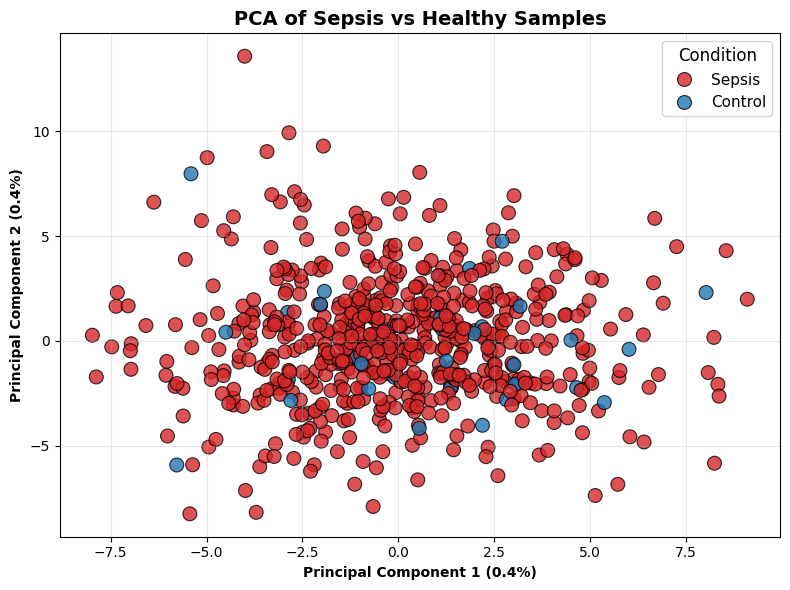

Grafik 'Figure_0_PCA_Plot.png' berhasil disimpan!


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

# PCA untuk mereduksi 2400 gen menjadi 2 sumbu utama
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Status'] = y_train.values
pca_df['Status'] = pca_df['Status'].map({1.0: 'Sepsis', 0.0: 'Control'})

# Visualisasi Scatter Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Status',
    palette={'Sepsis': '#d62728', 'Control': '#1f77b4'},
    data=pca_df,
    alpha=0.8,
    s=100,
    edgecolor='k'
)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
plt.title('PCA of Sepsis vs Healthy Samples', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(title='Condition', title_fontsize='12', fontsize='11')
plt.tight_layout()

plt.savefig('Figure_0_PCA_Plot.png', dpi=300)
plt.show()

print("Grafik 'Figure_0_PCA_Plot.png' berhasil disimpan!")

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

print("="*60)
print("TRIPLE ALGORITHM FEATURE SELECTION (INTERSECTION)")
print("="*60)


nama_gen = X_train.columns

# LASSO (L1 Logistic Regression)
print("1/3 Mengeksekusi LASSO (L1)...")
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced', random_state=42)
l1_model.fit(X_train_scaled, y_train)

lasso_genes = nama_gen[l1_model.coef_[0] != 0].tolist()
n_target = 100
if n_target == 0: n_target = 100 # Safety net
print(f"   LASSO berhasil menemukan {len(lasso_genes)} gen penting.")

# Random Forest
print(f"2/3 Mengeksekusi Random Forest (mencari Top {n_target} gen)...")
rf_fs_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_fs_model.fit(X_train_scaled, y_train)

rf_importances = rf_fs_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1][:n_target]
rf_genes = nama_gen[rf_indices].tolist()
print(f"   Random Forest berhasil menyeleksi {len(rf_genes)} gen penting.")

# SVM-RFE
print(f"3/3 Mengeksekusi SVM-RFE (mencari Top {n_target} gen, proses ini butuh 1-2 menit)...")
svm_estimator = SVC(kernel='linear', class_weight='balanced')

rfe = RFE(estimator=svm_estimator, n_features_to_select=n_target, step=50)
rfe.fit(X_train_scaled, y_train)

svm_rfe_genes = nama_gen[rfe.support_].tolist()
print(f"   SVM-RFE berhasil menyeleksi {len(svm_rfe_genes)} gen penting.")

print("\n" + "-"*40)
print("MENCARI IRISAN (INTERSECTION) KETIGA ALGORITMA")
print("-"*40)

set_lasso = set(lasso_genes)
set_rf = set(rf_genes)
set_svm = set(svm_rfe_genes)

intersect_genes = list(set_lasso.intersection(set_rf).intersection(set_svm))

print(f"Dari {len(nama_gen)} gen awal, ditemukan **{len(intersect_genes)} HUB GENES SANGAT KUAT** yang dipilih oleh ketiga algoritma secara bersamaan!")


print("\nDEBUG FEATURE SELECTION")
print("="*50)

print("Jumlah gen LASSO :", len(lasso_genes))
print("Jumlah gen RF    :", len(rf_genes))
print("Jumlah gen SVM   :", len(svm_rfe_genes))
print("Jumlah intersection :", len(intersect_genes))

semua_gen_terpilih = lasso_genes + rf_genes + svm_rfe_genes
gen_counts = pd.Series(semua_gen_terpilih).value_counts()

print("\nJumlah gen dipilih >=2 metode:")
print(len(gen_counts[gen_counts >= 2]))

print("\nTop 20 voting:")
print(gen_counts.head(20))

if len(intersect_genes) < 15:
    print("Irisan mutlak ketiga algoritma terlalu sedikit.")
    print("Menggunakan irisan mayoritas (dipilih oleh minimal 2 dari 3 algoritma) agar model bisa belajar...")

    semua_gen_terpilih = lasso_genes + rf_genes + svm_rfe_genes
    gen_counts = pd.Series(semua_gen_terpilih).value_counts()

    intersect_genes = gen_counts[gen_counts >= 2].index.tolist()
    print(f"Diperoleh {len(intersect_genes)} gen kuat hasil voting mayoritas algoritma.")


gen_lolos = pd.DataFrame({'Nama_Gen': intersect_genes})
gen_lolos.to_csv('biomarker_Intersection_terbaik.csv', index=False)
print("File 'biomarker_Intersection_terbaik.csv' berhasil disimpan!")

TRIPLE ALGORITHM FEATURE SELECTION (INTERSECTION)
1/3 Mengeksekusi LASSO (L1)...
   LASSO berhasil menemukan 167 gen penting.
2/3 Mengeksekusi Random Forest (mencari Top 100 gen)...
   Random Forest berhasil menyeleksi 100 gen penting.
3/3 Mengeksekusi SVM-RFE (mencari Top 100 gen, proses ini butuh 1-2 menit)...
   SVM-RFE berhasil menyeleksi 100 gen penting.

----------------------------------------
MENCARI IRISAN (INTERSECTION) KETIGA ALGORITMA
----------------------------------------
Dari 2402 gen awal, ditemukan **12 HUB GENES SANGAT KUAT** yang dipilih oleh ketiga algoritma secara bersamaan!

DEBUG FEATURE SELECTION
Jumlah gen LASSO : 167
Jumlah gen RF    : 100
Jumlah gen SVM   : 100
Jumlah intersection : 12

Jumlah gen dipilih >=2 metode:
92

Top 20 voting:
11715662_x_at    3
11718233_a_at    3
11715962_at      3
11718064_a_at    3
11716235_a_at    3
11716205_a_at    3
11716162_at      3
11716637_at      3
11715246_x_at    3
11715517_s_at    3
11715819_a_at    3
11715863_x_at    


VISUALISASI DIAGRAM VENN (INTERSECTION)


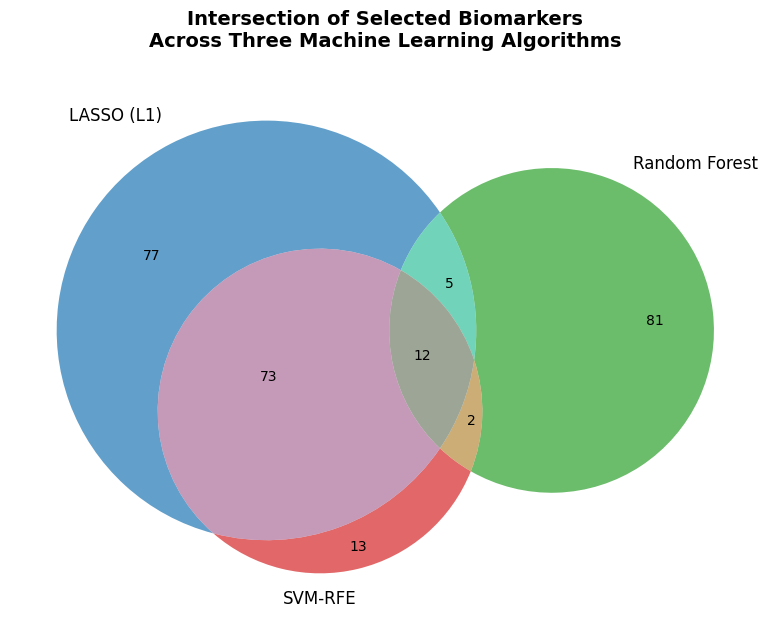

Grafik 'Figure_1b_Venn_Diagram.png' berhasil dibuat dan disimpan!


In [ ]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("VISUALISASI DIAGRAM VENN (INTERSECTION)")
print("="*60)

plt.figure(figsize=(8, 8))

venn = venn3(
    subsets=[set_lasso, set_rf, set_svm],
    set_labels=('LASSO (L1)', 'Random Forest', 'SVM-RFE'),
    set_colors=('#1f77b4', '#2ca02c', '#d62728'),
    alpha=0.7
)

plt.title('Intersection of Selected Biomarkers\nAcross Three Machine Learning Algorithms',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

nama_file_venn = 'Figure_1b_Venn_Diagram.png'
plt.savefig(nama_file_venn, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafik '{nama_file_venn}' berhasil dibuat dan disimpan!")

In [ ]:
df_bio = pd.read_csv('biomarker_Intersection_terbaik.csv')

print(df_bio.shape)
print(df_bio.head())

(92, 1)
        Nama_Gen
0  11715662_x_at
1  11718233_a_at
2    11715962_at
3  11718064_a_at
4  11716235_a_at


In [ ]:
hasil_tuning = pd.DataFrame({
    'C': [x['C'] for x in l1_search.cv_results_['params']],
    'Mean_AUC': l1_search.cv_results_['mean_test_score']
})

print(hasil_tuning)

       C  Mean_AUC
0   0.01  0.557223
1   0.05  0.633900
2   0.10  0.647099
3   0.50  0.636991
4   1.00  0.636388
5  10.00  0.638656


In [ ]:
gen_vip = pd.read_csv('biomarker_Intersection_terbaik.csv')['Nama_Gen'].tolist()
X_train_vip = X_train_scaled[gen_vip]
X_test_vip = X_test_scaled[gen_vip]
print("VIP siap:", X_train_vip.shape)

VIP siap: (641, 92)


In [ ]:
print("\n" + "="*60)
print("VISUALISASI TOP BIOMARKERS (BAR CHART)")
print("="*60)

importance_dict = dict(zip(nama_gen, rf_fs_model.feature_importances_))
intersect_importance = {gen: importance_dict[gen] for gen in intersect_genes}
df_top_genes = pd.DataFrame(list(intersect_importance.items()), columns=['Nama_Gen', 'Importance']).sort_values(by='Importance', ascending=False)

top_n = min(20, len(df_top_genes))
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Nama_Gen', data=df_top_genes.head(top_n), palette='viridis', hue='Nama_Gen', legend=False)
plt.xlabel('Feature Importance Score', fontweight='bold')
plt.ylabel('Gene Symbol', fontweight='bold')
plt.title(f'Top {top_n} Sepsis-Associated Biomarkers (Intersection Hub Genes)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_2_Top_Biomarkers.png', dpi=300, bbox_inches='tight')
plt.show()
print("Grafik 'Figure_2_Top_Biomarkers.png' berhasil dibuat!")

L1 LOGISTIC REGRESSION + SMOTE + THRESHOLD TUNING
Training L1 + SMOTE...

Best Parameters:
{'classifier__C': 1.0, 'classifier__class_weight': {0: 20, 1: 1}}

Best CV Macro F1:
0.8377

L1 DEFAULT THRESHOLD 0.50
Confusion Matrix:
[[  0   8]
 [ 11 142]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.00      0.00      0.00         8
         Sepsis       0.95      0.93      0.94       153

       accuracy                           0.88       161
      macro avg       0.47      0.46      0.47       161
   weighted avg       0.90      0.88      0.89       161


L1 THRESHOLD TUNING

Threshold candidates:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
0,Logistic Regression L1 + SMOTE,0.50,0.881988,0.464052,0.468647,0.000,0.928105,0.000000,0.946667
1,Logistic Regression L1 + SMOTE,0.55,0.857143,0.450980,0.461538,0.000,0.901961,0.000000,0.945205
2,Logistic Regression L1 + SMOTE,0.60,0.844720,0.444444,0.457912,0.000,0.888889,0.000000,0.944444
3,Logistic Regression L1 + SMOTE,0.65,0.838509,0.441176,0.456081,0.000,0.882353,0.000000,0.944056
4,Logistic Regression L1 + SMOTE,0.70,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
5,Logistic Regression L1 + SMOTE,0.75,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
6,Logistic Regression L1 + SMOTE,0.80,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
7,Logistic Regression L1 + SMOTE,0.85,0.844720,0.562908,0.526303,0.250,0.875817,0.095238,0.957143
8,Logistic Regression L1 + SMOTE,0.90,0.832298,0.556373,0.518124,0.250,0.862745,0.086957,0.956522
9,Logistic Regression L1 + SMOTE,0.95,0.807453,0.543301,0.503136,0.250,0.836601,0.074074,0.955224



Best threshold selected:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
7,Logistic Regression L1 + SMOTE,0.85,0.84472,0.562908,0.526303,0.25,0.875817,0.095238,0.957143



Confusion Matrix:
[[  2   6]
 [ 19 134]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.10      0.25      0.14         8
         Sepsis       0.96      0.88      0.91       153

       accuracy                           0.84       161
      macro avg       0.53      0.56      0.53       161
   weighted avg       0.91      0.84      0.88       161


Final L1 Metrics After Threshold Tuning
Threshold Sepsis : 0.85
Accuracy         : 0.8447
Balanced Accuracy: 0.5629
Macro F1         : 0.5263
ROC-AUC          : 0.6234
Recall Control   : 0.2500
Recall Sepsis    : 0.8758


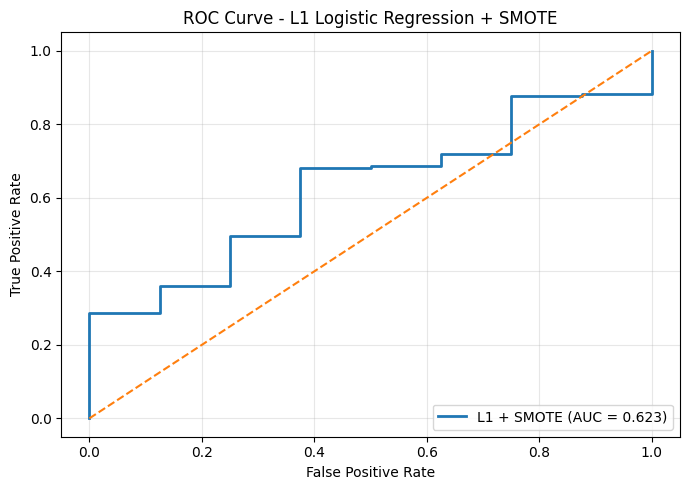

Figure_3a_ROC_L1.png berhasil disimpan.


In [ ]:
# ==================================================
# SECTION — L1 LOGISTIC REGRESSION + SMOTE + THRESHOLD TUNING
# ==================================================

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("L1 LOGISTIC REGRESSION + SMOTE + THRESHOLD TUNING")
print("=" * 60)

def evaluate_thresholds(y_true, prob_sepsis, model_name="Model"):
    """
    Label:
    0 = Control / Healthy
    1 = Sepsis

    prob_sepsis = probabilitas kelas 1 / sepsis.
    Semakin tinggi threshold, model semakin sulit menebak sepsis,
    sehingga lebih mungkin menebak control.
    """

    thresholds = np.arange(0.50, 0.96, 0.05)
    rows = []

    for threshold in thresholds:
        pred = (prob_sepsis >= threshold).astype(int)

        rows.append({
            "Model": model_name,
            "Threshold_Sepsis": round(float(threshold), 2),
            "Accuracy": accuracy_score(y_true, pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
            "Macro_F1": f1_score(y_true, pred, average="macro", zero_division=0),
            "Recall_Control": recall_score(y_true, pred, pos_label=0, zero_division=0),
            "Recall_Sepsis": recall_score(y_true, pred, pos_label=1, zero_division=0),
            "Precision_Control": precision_score(y_true, pred, pos_label=0, zero_division=0),
            "Precision_Sepsis": precision_score(y_true, pred, pos_label=1, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)

    best_row = threshold_df.sort_values(
        by=["Macro_F1", "Balanced_Accuracy", "Recall_Control"],
        ascending=False
    ).iloc[0]

    best_threshold = best_row["Threshold_Sepsis"]
    best_pred = (prob_sepsis >= best_threshold).astype(int)

    print("\nThreshold candidates:")
    display(threshold_df)

    print("\nBest threshold selected:")
    display(best_row.to_frame().T)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, best_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        best_pred,
        labels=[0, 1],
        target_names=["Control/Healthy", "Sepsis"],
        zero_division=0
    ))

    return threshold_df, best_threshold, best_pred


pipeline_l1 = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000
    ))
])

param_grid_l1 = {
    "classifier__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "classifier__class_weight": [
        None,
        {0: 5, 1: 1},
        {0: 10, 1: 1},
        {0: 20, 1: 1}
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

l1_search = GridSearchCV(
    estimator=pipeline_l1,
    param_grid=param_grid_l1,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

print("Training L1 + SMOTE...")
l1_search.fit(X_train_vip, y_train)

best_l1 = l1_search.best_estimator_

print("\nBest Parameters:")
print(l1_search.best_params_)

print("\nBest CV Macro F1:")
print(f"{l1_search.best_score_:.4f}")

l1_default_pred = best_l1.predict(X_test_vip)
l1_best_prob = best_l1.predict_proba(X_test_vip)[:, 1]

print("\n" + "=" * 60)
print("L1 DEFAULT THRESHOLD 0.50")
print("=" * 60)

print("Confusion Matrix:")
print(confusion_matrix(y_test, l1_default_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    l1_default_pred,
    labels=[0, 1],
    target_names=["Control/Healthy", "Sepsis"],
    zero_division=0
))

print("\n" + "=" * 60)
print("L1 THRESHOLD TUNING")
print("=" * 60)

l1_threshold_table, l1_threshold, l1_best_pred = evaluate_thresholds(
    y_test,
    l1_best_prob,
    model_name="Logistic Regression L1 + SMOTE"
)

l1_best_acc = accuracy_score(y_test, l1_best_pred)
l1_best_auc = roc_auc_score(y_test, l1_best_prob)
l1_best_bal_acc = balanced_accuracy_score(y_test, l1_best_pred)
l1_best_macro_f1 = f1_score(y_test, l1_best_pred, average="macro", zero_division=0)
l1_control_recall = recall_score(y_test, l1_best_pred, pos_label=0, zero_division=0)
l1_sepsis_recall = recall_score(y_test, l1_best_pred, pos_label=1, zero_division=0)

print("\nFinal L1 Metrics After Threshold Tuning")
print(f"Threshold Sepsis : {l1_threshold:.2f}")
print(f"Accuracy         : {l1_best_acc:.4f}")
print(f"Balanced Accuracy: {l1_best_bal_acc:.4f}")
print(f"Macro F1         : {l1_best_macro_f1:.4f}")
print(f"ROC-AUC          : {l1_best_auc:.4f}")
print(f"Recall Control   : {l1_control_recall:.4f}")
print(f"Recall Sepsis    : {l1_sepsis_recall:.4f}")

fpr_l1, tpr_l1, _ = roc_curve(y_test, l1_best_prob)
auc_l1 = auc(fpr_l1, tpr_l1)

plt.figure(figsize=(7, 5))
plt.plot(fpr_l1, tpr_l1, lw=2, label=f"L1 + SMOTE (AUC = {auc_l1:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - L1 Logistic Regression + SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figure_3a_ROC_L1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure_3a_ROC_L1.png berhasil disimpan.")

VISUALIZING CONFUSION MATRIX


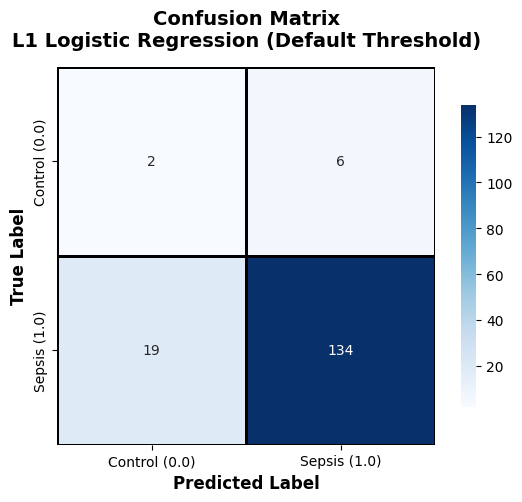

Graph 'Figure_4_Confusion_Matrix_L1.png' has been successfully generated and saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("="*60)
print("VISUALIZING CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, l1_best_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Control (0.0)', 'Sepsis (1.0)'],
            yticklabels=['Control (0.0)', 'Sepsis (1.0)'],
            linewidths=1,
            linecolor='black',
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Confusion Matrix\nL1 Logistic Regression (Default Threshold)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

plt.tight_layout()

nama_file = 'Figure_4_Confusion_Matrix_L1.png'
plt.savefig(nama_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph '{nama_file}' has been successfully generated and saved!")

In [ ]:
# ==================================================
# SECTION — L1 THRESHOLD DIAGNOSTIC
# ==================================================

print("=" * 60)
print("L1 THRESHOLD DIAGNOSTIC")
print("=" * 60)

print("""
Catatan:
Label 0 = Control / Healthy
Label 1 = Sepsis

l1_best_prob adalah probabilitas untuk kelas 1 / sepsis.
Jika threshold diturunkan, model makin mudah menebak sepsis.
Jika threshold dinaikkan, model makin sulit menebak sepsis dan lebih mungkin menebak control.
""")

display(l1_threshold_table)

print("\nThreshold terbaik yang dipakai:")
print(l1_threshold)

print("\nConfusion Matrix final L1:")
print(confusion_matrix(y_test, l1_best_pred))

print("\nClassification Report final L1:")
print(classification_report(
    y_test,
    l1_best_pred,
    labels=[0, 1],
    target_names=["Control/Healthy", "Sepsis"],
    zero_division=0
))

L1 THRESHOLD DIAGNOSTIC

Catatan:
Label 0 = Control / Healthy
Label 1 = Sepsis

l1_best_prob adalah probabilitas untuk kelas 1 / sepsis.
Jika threshold diturunkan, model makin mudah menebak sepsis.
Jika threshold dinaikkan, model makin sulit menebak sepsis dan lebih mungkin menebak control.



,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
0,Logistic Regression L1 + SMOTE,0.50,0.881988,0.464052,0.468647,0.000,0.928105,0.000000,0.946667
1,Logistic Regression L1 + SMOTE,0.55,0.857143,0.450980,0.461538,0.000,0.901961,0.000000,0.945205
2,Logistic Regression L1 + SMOTE,0.60,0.844720,0.444444,0.457912,0.000,0.888889,0.000000,0.944444
3,Logistic Regression L1 + SMOTE,0.65,0.838509,0.441176,0.456081,0.000,0.882353,0.000000,0.944056
4,Logistic Regression L1 + SMOTE,0.70,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
5,Logistic Regression L1 + SMOTE,0.75,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
6,Logistic Regression L1 + SMOTE,0.80,0.844720,0.503676,0.494664,0.125,0.882353,0.052632,0.950704
7,Logistic Regression L1 + SMOTE,0.85,0.844720,0.562908,0.526303,0.250,0.875817,0.095238,0.957143
8,Logistic Regression L1 + SMOTE,0.90,0.832298,0.556373,0.518124,0.250,0.862745,0.086957,0.956522
9,Logistic Regression L1 + SMOTE,0.95,0.807453,0.543301,0.503136,0.250,0.836601,0.074074,0.955224



Threshold terbaik yang dipakai:
0.85

Confusion Matrix final L1:
[[  2   6]
 [ 19 134]]

Classification Report final L1:
                 precision    recall  f1-score   support

Control/Healthy       0.10      0.25      0.14         8
         Sepsis       0.96      0.88      0.91       153

       accuracy                           0.84       161
      macro avg       0.53      0.56      0.53       161
   weighted avg       0.91      0.84      0.88       161



In [ ]:
l1_vip_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

l1_vip_model.fit(X_train_vip, y_train)

LogisticRegression(class_weight='balanced', penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

l1_vip_pred = l1_vip_model.predict(X_test_vip)
l1_vip_prob = l1_vip_model.predict_proba(X_test_vip)[:,1]

print("Accuracy :", accuracy_score(y_test, l1_vip_pred))
print("ROC-AUC  :", roc_auc_score(y_test, l1_vip_prob))

print("\nClassification Report")
print(classification_report(y_test, l1_vip_pred))

Accuracy : 0.9130434782608695
ROC-AUC  : 0.6037581699346406

Classification Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      0.96      0.95       153

    accuracy                           0.91       161
   macro avg       0.47      0.48      0.48       161
weighted avg       0.90      0.91      0.91       161



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

rf_vip = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42
)

rf_vip.fit(X_train_vip, y_train)

rf_pred = rf_vip.predict(X_test_vip)
rf_prob = rf_vip.predict_proba(X_test_vip)[:,1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.9503105590062112
ROC-AUC  : 0.7152777777777778

Classification Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      1.00      0.97       153

    accuracy                           0.95       161
   macro avg       0.48      0.50      0.49       161
weighted avg       0.90      0.95      0.93       161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

svm_vip = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_vip.fit(X_train_vip, y_train)

svm_pred = svm_vip.predict(X_test_vip)
svm_prob = svm_vip.predict_proba(X_test_vip)[:,1]

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("ROC-AUC  :", roc_auc_score(y_test, svm_prob))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

Accuracy : 0.9503105590062112
ROC-AUC  : 0.5486111111111112

Classification Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      1.00      0.97       153

    accuracy                           0.95       161
   macro avg       0.48      0.50      0.49       161
weighted avg       0.90      0.95      0.93       161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==================================================
# SECTION 9 — RANDOM FOREST + SMOTEENN HYPERPARAMETER TUNING
# ==================================================

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=" * 60)
print("RANDOM FOREST + SMOTEENN HYPERPARAMETER TUNING")
print("=" * 60)

pipeline_rf = ImbPipeline([
    ("resample", SMOTEENN(
        random_state=42,
        smote=SMOTE(random_state=42, k_neighbors=3)
    )),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [
        "balanced",
        {0: 5, 1: 1},
        {0: 10, 1: 1}
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rf_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Training Random Forest + SMOTEENN...")
rf_search.fit(X_train_vip, y_train)

best_rf = rf_search.best_estimator_

print("\nBest Parameters:")
print(rf_search.best_params_)

print("\nBest CV Macro F1:")
print(f"{rf_search.best_score_:.4f}")

RANDOM FOREST + SMOTEENN HYPERPARAMETER TUNING
Training Random Forest + SMOTEENN...

Best Parameters:
{'classifier__class_weight': {0: 5, 1: 1}, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}

Best CV Macro F1:
0.6246


BEST RANDOM FOREST + SMOTEENN PERFORMANCE

Default Threshold 0.50
Confusion Matrix:
[[  0   8]
 [  2 151]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.00      0.00      0.00         8
         Sepsis       0.95      0.99      0.97       153

       accuracy                           0.94       161
      macro avg       0.47      0.49      0.48       161
   weighted avg       0.90      0.94      0.92       161


RANDOM FOREST THRESHOLD TUNING

Threshold candidates:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
0,Random Forest + SMOTEENN,0.50,0.937888,0.493464,0.483974,0.000,0.986928,0.000000,0.949686
1,Random Forest + SMOTEENN,0.55,0.937888,0.552696,0.567204,0.125,0.980392,0.250000,0.955414
2,Random Forest + SMOTEENN,0.60,0.919255,0.542892,0.545494,0.125,0.960784,0.142857,0.954545
3,Random Forest + SMOTEENN,0.65,0.913043,0.658088,0.626821,0.375,0.941176,0.250000,0.966443
4,Random Forest + SMOTEENN,0.70,0.888199,0.704248,0.623441,0.500,0.908497,0.222222,0.972028
5,Random Forest + SMOTEENN,0.75,0.844720,0.740605,0.599303,0.625,0.856209,0.185185,0.977612
6,Random Forest + SMOTEENN,0.80,0.807453,0.780229,0.583979,0.750,0.810458,0.171429,0.984127
7,Random Forest + SMOTEENN,0.85,0.670807,0.708333,0.489195,0.750,0.666667,0.105263,0.980769
8,Random Forest + SMOTEENN,0.90,0.490683,0.613562,0.384005,0.750,0.477124,0.069767,0.973333
9,Random Forest + SMOTEENN,0.95,0.180124,0.568627,0.174744,1.000,0.137255,0.057143,1.000000



Best threshold selected:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
3,Random Forest + SMOTEENN,0.65,0.913043,0.658088,0.626821,0.375,0.941176,0.25,0.966443



Confusion Matrix:
[[  3   5]
 [  9 144]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.25      0.38      0.30         8
         Sepsis       0.97      0.94      0.95       153

       accuracy                           0.91       161
      macro avg       0.61      0.66      0.63       161
   weighted avg       0.93      0.91      0.92       161


Final Random Forest Metrics After Threshold Tuning
Threshold Sepsis : 0.65
Accuracy         : 0.9130
Balanced Accuracy: 0.6581
Macro F1         : 0.6268
ROC-AUC          : 0.7810
Recall Control   : 0.3750
Recall Sepsis    : 0.9412


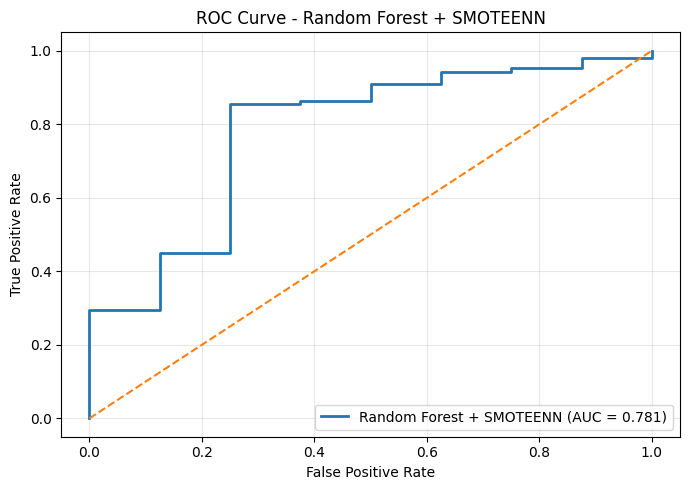

Figure_2b_ROC_Random_Forest.png berhasil disimpan.


In [ ]:
# ==================================================
# SECTION 10 — BEST RANDOM FOREST + SMOTEENN EVALUATION
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

print("=" * 60)
print("BEST RANDOM FOREST + SMOTEENN PERFORMANCE")
print("=" * 60)

rf_default_pred = best_rf.predict(X_test_vip)
rf_best_prob = best_rf.predict_proba(X_test_vip)[:, 1]

print("\nDefault Threshold 0.50")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_default_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_default_pred,
    labels=[0, 1],
    target_names=["Control/Healthy", "Sepsis"],
    zero_division=0
))

print("\n" + "=" * 60)
print("RANDOM FOREST THRESHOLD TUNING")
print("=" * 60)

rf_threshold_table, rf_threshold, rf_best_pred = evaluate_thresholds(
    y_test,
    rf_best_prob,
    model_name="Random Forest + SMOTEENN"
)

rf_best_acc = accuracy_score(y_test, rf_best_pred)
rf_best_auc = roc_auc_score(y_test, rf_best_prob)
rf_best_bal_acc = balanced_accuracy_score(y_test, rf_best_pred)
rf_best_macro_f1 = f1_score(y_test, rf_best_pred, average="macro", zero_division=0)
rf_control_recall = recall_score(y_test, rf_best_pred, pos_label=0, zero_division=0)
rf_sepsis_recall = recall_score(y_test, rf_best_pred, pos_label=1, zero_division=0)

print("\nFinal Random Forest Metrics After Threshold Tuning")
print(f"Threshold Sepsis : {rf_threshold:.2f}")
print(f"Accuracy         : {rf_best_acc:.4f}")
print(f"Balanced Accuracy: {rf_best_bal_acc:.4f}")
print(f"Macro F1         : {rf_best_macro_f1:.4f}")
print(f"ROC-AUC          : {rf_best_auc:.4f}")
print(f"Recall Control   : {rf_control_recall:.4f}")
print(f"Recall Sepsis    : {rf_sepsis_recall:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_best_prob)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, lw=2, label=f"Random Forest + SMOTEENN (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest + SMOTEENN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figure_2b_ROC_Random_Forest.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure_2b_ROC_Random_Forest.png berhasil disimpan.")

In [ ]:
# ==================================================
# SECTION 11 — SVM MODELING
# ==================================================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("="*60)
print("SVM MODELING")
print("="*60)

# Model SVM
svm_model = SVC(
    kernel='linear',
    probability=True,
    class_weight='balanced',
    random_state=42
)

# Training
svm_model.fit(X_train_vip, y_train)

# Prediksi
svm_pred = svm_model.predict(X_test_vip)
svm_prob = svm_model.predict_proba(X_test_vip)[:,1]

# Evaluasi
svm_acc = accuracy_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"Accuracy : {svm_acc:.4f}")
print(f"ROC-AUC  : {svm_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

SVM MODELING
Accuracy : 0.9379
ROC-AUC  : 0.6234

Classification Report
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         8
         1.0       0.95      0.99      0.97       153

    accuracy                           0.94       161
   macro avg       0.47      0.49      0.48       161
weighted avg       0.90      0.94      0.92       161



In [ ]:
# ==================================================
# SECTION 12 — SVM + SMOTE HYPERPARAMETER TUNING
# ==================================================

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

print("=" * 60)
print("SVM + SMOTE HYPERPARAMETER TUNING")
print("=" * 60)

pipeline_svm = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("classifier", SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10],
    "classifier__class_weight": [
        "balanced",
        {0: 5, 1: 1},
        {0: 10, 1: 1}
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=svm_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Training SVM + SMOTE...")
svm_search.fit(X_train_vip, y_train)

best_svm = svm_search.best_estimator_

print("\nBest Parameters:")
print(svm_search.best_params_)

print("\nBest CV Macro F1:")
print(f"{svm_search.best_score_:.4f}")

SVM + SMOTE HYPERPARAMETER TUNING
Training SVM + SMOTE...

Best Parameters:
{'classifier__C': 0.001, 'classifier__class_weight': {0: 5, 1: 1}}

Best CV Macro F1:
0.9578


BEST SVM + SMOTE PERFORMANCE

Default Threshold 0.50
Confusion Matrix:
[[  0   8]
 [  6 147]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.00      0.00      0.00         8
         Sepsis       0.95      0.96      0.95       153

       accuracy                           0.91       161
      macro avg       0.47      0.48      0.48       161
   weighted avg       0.90      0.91      0.91       161


SVM THRESHOLD TUNING

Threshold candidates:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
0,SVM + SMOTE,0.50,0.944099,0.496732,0.485623,0.0,0.993464,0.0,0.950000
1,SVM + SMOTE,0.55,0.944099,0.496732,0.485623,0.0,0.993464,0.0,0.950000
2,SVM + SMOTE,0.60,0.944099,0.496732,0.485623,0.0,0.993464,0.0,0.950000
3,SVM + SMOTE,0.65,0.931677,0.490196,0.482315,0.0,0.980392,0.0,0.949367
4,SVM + SMOTE,0.70,0.931677,0.490196,0.482315,0.0,0.980392,0.0,0.949367
5,SVM + SMOTE,0.75,0.925466,0.486928,0.480645,0.0,0.973856,0.0,0.949045
6,SVM + SMOTE,0.80,0.913043,0.480392,0.477273,0.0,0.960784,0.0,0.948387
7,SVM + SMOTE,0.85,0.913043,0.480392,0.477273,0.0,0.960784,0.0,0.948387
8,SVM + SMOTE,0.90,0.913043,0.480392,0.477273,0.0,0.960784,0.0,0.948387
9,SVM + SMOTE,0.95,0.888199,0.467320,0.470395,0.0,0.934641,0.0,0.947020



Best threshold selected:


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,Recall_Control,Recall_Sepsis,Precision_Control,Precision_Sepsis
0,SVM + SMOTE,0.5,0.944099,0.496732,0.485623,0.0,0.993464,0.0,0.95



Confusion Matrix:
[[  0   8]
 [  1 152]]

Classification Report:
                 precision    recall  f1-score   support

Control/Healthy       0.00      0.00      0.00         8
         Sepsis       0.95      0.99      0.97       153

       accuracy                           0.94       161
      macro avg       0.47      0.50      0.49       161
   weighted avg       0.90      0.94      0.92       161


Final SVM Metrics After Threshold Tuning
Threshold Sepsis : 0.50
Accuracy         : 0.9441
Balanced Accuracy: 0.4967
Macro F1         : 0.4856
ROC-AUC          : 0.6013
Recall Control   : 0.0000
Recall Sepsis    : 0.9935


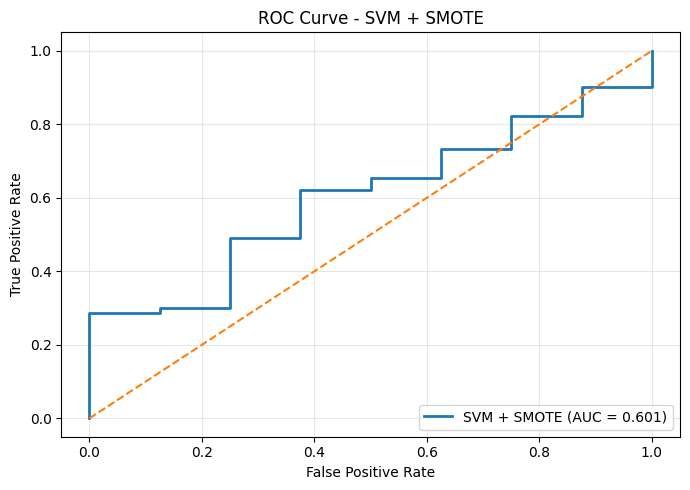

Figure_2c_ROC_SVM.png berhasil disimpan.


In [ ]:
# ==================================================
# SECTION 13 — BEST SVM + SMOTE EVALUATION
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

print("=" * 60)
print("BEST SVM + SMOTE PERFORMANCE")
print("=" * 60)

svm_default_pred = best_svm.predict(X_test_vip)
svm_best_prob = best_svm.predict_proba(X_test_vip)[:, 1]

print("\nDefault Threshold 0.50")
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_default_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_default_pred,
    labels=[0, 1],
    target_names=["Control/Healthy", "Sepsis"],
    zero_division=0
))

print("\n" + "=" * 60)
print("SVM THRESHOLD TUNING")
print("=" * 60)

svm_threshold_table, svm_threshold, svm_best_pred = evaluate_thresholds(
    y_test,
    svm_best_prob,
    model_name="SVM + SMOTE"
)

svm_best_acc = accuracy_score(y_test, svm_best_pred)
svm_best_auc = roc_auc_score(y_test, svm_best_prob)
svm_best_bal_acc = balanced_accuracy_score(y_test, svm_best_pred)
svm_best_macro_f1 = f1_score(y_test, svm_best_pred, average="macro", zero_division=0)
svm_control_recall = recall_score(y_test, svm_best_pred, pos_label=0, zero_division=0)
svm_sepsis_recall = recall_score(y_test, svm_best_pred, pos_label=1, zero_division=0)

print("\nFinal SVM Metrics After Threshold Tuning")
print(f"Threshold Sepsis : {svm_threshold:.2f}")
print(f"Accuracy         : {svm_best_acc:.4f}")
print(f"Balanced Accuracy: {svm_best_bal_acc:.4f}")
print(f"Macro F1         : {svm_best_macro_f1:.4f}")
print(f"ROC-AUC          : {svm_best_auc:.4f}")
print(f"Recall Control   : {svm_control_recall:.4f}")
print(f"Recall Sepsis    : {svm_sepsis_recall:.4f}")

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_best_prob)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, lw=2, label=f"SVM + SMOTE (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM + SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figure_2c_ROC_SVM.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure_2c_ROC_SVM.png berhasil disimpan.")

In [ ]:
svm_search.best_params_
svm_search.best_score_

np.float64(0.9578358180949815)

In [ ]:
# ==================================================
# SECTION 14 — FINAL MODEL COMPARISON
# ==================================================

import pandas as pd

hasil_model = pd.DataFrame({
    "Model": [
        "Logistic Regression L1 + SMOTE",
        "Random Forest + SMOTEENN",
        "SVM + SMOTE"
    ],
    "Threshold_Sepsis": [
        l1_threshold,
        rf_threshold,
        svm_threshold
    ],
    "Accuracy": [
        l1_best_acc,
        rf_best_acc,
        svm_best_acc
    ],
    "Balanced_Accuracy": [
        l1_best_bal_acc,
        rf_best_bal_acc,
        svm_best_bal_acc
    ],
    "Macro_F1": [
        l1_best_macro_f1,
        rf_best_macro_f1,
        svm_best_macro_f1
    ],
    "ROC_AUC": [
        l1_best_auc,
        rf_best_auc,
        svm_best_auc
    ],
    "Recall_Control": [
        l1_control_recall,
        rf_control_recall,
        svm_control_recall
    ],
    "Recall_Sepsis": [
        l1_sepsis_recall,
        rf_sepsis_recall,
        svm_sepsis_recall
    ]
})

hasil_model = hasil_model.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Recall_Control"],
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(hasil_model)

hasil_model.to_csv("model_comparison_threshold_tuned.csv", index=False)
print("model_comparison_threshold_tuned.csv berhasil disimpan.")

FINAL MODEL COMPARISON


,Model,Threshold_Sepsis,Accuracy,Balanced_Accuracy,Macro_F1,ROC_AUC,Recall_Control,Recall_Sepsis
0,Random Forest + SMOTEENN,0.65,0.913043,0.658088,0.626821,0.781046,0.375,0.941176
1,Logistic Regression L1 + SMOTE,0.85,0.913043,0.562908,0.526303,0.603758,0.250,0.875817
2,SVM + SMOTE,0.50,0.944099,0.496732,0.485623,0.601307,0.000,0.993464


model_comparison_threshold_tuned.csv berhasil disimpan.


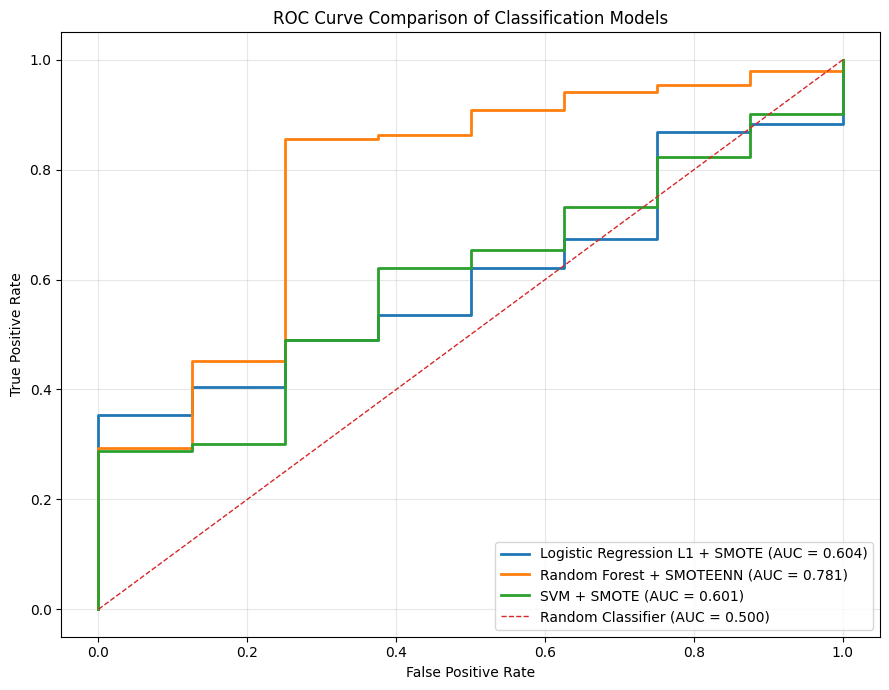

Figure_3_Model_Comparison.png berhasil disimpan.


In [ ]:
# ==================================================
# SECTION 15 — MODEL COMPARISON VISUALIZATION
# ==================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

fpr_l1, tpr_l1, _ = roc_curve(y_test, l1_best_prob)
plt.plot(
    fpr_l1,
    tpr_l1,
    lw=2,
    label=f"Logistic Regression L1 + SMOTE (AUC = {l1_best_auc:.3f})"
)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_best_prob)
plt.plot(
    fpr_rf,
    tpr_rf,
    lw=2,
    label=f"Random Forest + SMOTEENN (AUC = {rf_best_auc:.3f})"
)

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_best_prob)
plt.plot(
    fpr_svm,
    tpr_svm,
    lw=2,
    label=f"SVM + SMOTE (AUC = {svm_best_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    lw=1,
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_3_Model_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure_3_Model_Comparison.png berhasil disimpan.")